### Plate Reverb Implementation
This Notebook implements a mono-in, stereo-out plate reverb as described by Jon Dattorro in Effect Design Part 1: Reverberator and Other Filters.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display
import math

In [12]:
class DelayLine:

    # Initialize a fixed-length circular buffer and write pointer.
    def __init__(self, length, fillValue=0.0):
        self.length = int(length)
        # Fixed-size circular buffer for delayed samples.
        self.buffer = [fillValue] * self.length
        # -1 means no writes yet and first write lands at index 0.
        self.writeIdx = -1

    # Write one new sample into the line at the current time step.
    def write(self, sample):
        # Advance write pointer with wraparound, then store sample.
        self.writeIdx = (self.writeIdx + 1) % self.length
        self.buffer[self.writeIdx] = sample

    # Return the sample n positions behind the write pointer.
    def tap(self, n):
        n = int(n)
        readIdx = (self.writeIdx - n) % self.length # Read n samples behind write pointer.
        return self.buffer[readIdx]

    # Return the current delayed output, then write the new input sample.
    def process(self, sample):
        y = self.tap(self.length - 1)
        self.write(sample)
        return y

In [13]:
class OnePoleLowpassFilter:

    # Create a one-pole lowpass with damping or bandwidth control mapping.
    # Damping mode maps control directly to smoothing (higher control value = slower/smoother, more HF filtered)
    # Bandwidth mode inverts it (higher control value = faster/less smooth, less HF filtered).
    def __init__(self, control=0.5, mode="damping", initialState=0.0):
        self.mode = str(mode)
        self.control = None
        self.a = 0.0  # One-pole feedback coefficient (smoothing amount).
        self.z1 = float(initialState)
        self.setControl(control, mode)

    # Update the control value and mapping mode.
    def setControl(self, control, mode=None):
        if mode is not None:
            self.mode = str(mode).lower()
        control = float(control)  # User control amount.
        self.control = control
        
        # Pole coefficient in y[n] = (1-a)x[n] + a*y[n-1].
        self.a = control if self.mode == "damping" else (1.0 - control)  # Damping: more control --> more smoothing; bandwidth: inverse.

    # Process one sample through the filter.
    def process(self, x):
        x = float(x)
        y = (1.0 - self.a) * x + self.a * self.z1
        self.z1 = y
        return y

In [14]:
class ModulatedAllpass:

    # Initialize an allpass delay with sine LFO modulation.
    def __init__(self, maxDelaySamples, delaySamples, gain=0.5, sampleRate=48000.0, lfoRateHz=5.0, lfoDepthSamples=0.0, lfoPhase=0.0, fillValue=0.0):
        self.maxDelay = float(maxDelaySamples)  # Maximum allowed delay (samples)
        self.delay = float(delaySamples)  # Current base delay (samples)
        self.gain = float(gain)  # Allpass feedback/feedforward gain
        self.sampleRate = float(sampleRate)  # Sample rate for LFO increment
        self.lfoRate = float(lfoRateHz)  # LFO frequency in Hz
        self.lfoDepth = float(lfoDepthSamples)  # LFO depth in samples
        self.lfoPhase = float(lfoPhase)  # Current LFO phase (radians)
        self.buffer = [float(fillValue)] * (int(self.maxDelay) + 3)  # Delay buffer with guard samples
        self.writeIdx = -1  # Circular buffer write pointer
        self.apX1 = 0.0  # Previous input to interpolation allpass
        self.apY1 = 0.0  # Previous output of interpolation allpass
        self.setDelay(delaySamples)  # Clamp and store initial delay

    # Set base delay in samples
    def setDelay(self, delaySamples):
        d = float(delaySamples)
        if d < 0.0:
            d = 0.0
        if d > self.maxDelay:
            d = self.maxDelay
        self.delay = d

    # Return sample at point n
    def tap(self, n):
        d = float(n)
        
        #boundary checks
        if d < 0.0:
            d = 0.0
        
        if d > self.maxDelay:
            d = self.maxDelay

        # Fractional-delay interpolation setup
        nInt = int(d)  # Integer part of delay in samples
        frac = d - nInt  # Fractional part
        
        x0 = self.buffer[(self.writeIdx - nInt) % len(self.buffer)]  # Read integer-delay sample
        
        if frac < 1e-12:  # If effectively integer delay, skip interpolation
            return x0  # Return exact tap value

        eta = (1.0 - frac) / (1.0 + frac)  # Allpass interpolation coefficient
        y = eta * x0 + self.apX1 - eta * self.apY1  # One-pole allpass interpolation step
        self.apX1, self.apY1 = x0, y  # Save state for next interpolation call
        return y  # Return interpolated delayed sample

    # Process one sample through the allpass with LFO-modulated delay
    def process(self, x):
        # LFO modulates the base delay length in samples
        modDelay = self.delay + self.lfoDepth * math.sin(self.lfoPhase)
        
        # Read delayed sample, then compute allpass input/output pair
        d = self.tap(modDelay)
        w = float(x) + self.gain * d
        y = d - self.gain * w

        # Push current state into the delay buffer
        self.writeIdx = (self.writeIdx + 1) % len(self.buffer)
        self.buffer[self.writeIdx] = w
        
        return y

In [ ]:
# Core blocks
preDelay = DelayLine(int(0.020 * 48000))  # 20 ms at 48 kHz
lpf1 = OnePoleLowpassFilter(0.5, "bandwidth", 0.0)

# Input diffusers
apf1 = ModulatedAllpass(maxDelaySamples=210, delaySamples=210, gain=0.75)
apf2 = ModulatedAllpass(maxDelaySamples=158, delaySamples=158, gain=0.75)
apf3 = ModulatedAllpass(maxDelaySamples=561, delaySamples=561, gain=0.625)
apf4 = ModulatedAllpass(maxDelaySamples=410, delaySamples=410, gain=0.625)

# Decay
decay = 0.5

# Tank left
mapf1 = ModulatedAllpass(maxDelaySamples=1343 + 12, delaySamples=1343, gain=0.7, lfoRateHz=0.10, lfoDepthSamples=12)
delay1 = DelayLine(6241)
lpf2 = OnePoleLowpassFilter(0.5, "damping", 0.0)
apf5 = ModulatedAllpass(maxDelaySamples=3931, delaySamples=3931, gain=0.5)
delay2 = DelayLine(4681)

# Tank right
mapf2 = ModulatedAllpass(maxDelaySamples=995 + 12, delaySamples=995, gain=0.7, lfoRateHz=0.07, lfoDepthSamples=12)
delay3 = DelayLine(6590)
lpf3 = OnePoleLowpassFilter(0.5, "damping", 0.0)
apf6 = ModulatedAllpass(maxDelaySamples=2664, delaySamples=2664, gain=0.5)
delay4 = DelayLine(5505)

leftTankFeedback = 0.0
rightTankFeedback = 0.0

# Processes one input sample and reuses the previous tank output samples as cross-feedback.
def processReverbSample(x):
    global leftTankFeedback, rightTankFeedback

    preDelay.write(x)
    u = preDelay.tap(preDelay.length - 1)
    u = lpf1.process(u)

    u = apf1.process(u)
    u = apf2.process(u)
    u = apf3.process(u)
    u = apf4.process(u)

    inL = u + decay * rightTankFeedback
    inR = u + decay * leftTankFeedback

    sL = mapf1.process(inL)
    sL = delay1.process(sL)
    sL = lpf2.process(sL)
    sL = apf5.process(sL)
    leftTankFeedback = delay2.process(sL)

    sR = mapf2.process(inR)
    sR = delay3.process(sR)
    sR = lpf3.process(sR)
    sR = apf6.process(sR)
    rightTankFeedback = delay4.process(sR) # Updates global variable so next sample is affected

    yL = (delay1.tap(394) + delay1.tap(4401) - apf5.tap(2831) + delay2.tap(2954)
          - delay3.tap(2945) - apf6.tap(277) - delay4.tap(1066))

    yR = (delay3.tap(522) + delay3.tap(5368) - apf6.tap(1817) + delay4.tap(3956)
          - delay1.tap(3124) - apf5.tap(496) - delay2.tap(179))

    return yL, yR

In [16]:
# Spectrogram function for visualization. (used in previous assignments)
def spectrogram(x, Fs, title='Log-Frequency Spectrogram', NFFT=4096, noverlap=3584):
    f, t, Sxx = signal.spectrogram(x, fs=Fs, window='hann', nperseg=NFFT, noverlap=noverlap, nfft=8192, scaling='spectrum')
    Sxx_db = 10 * np.log10(Sxx + 1e-20)
    Sxx_db -= np.max(Sxx_db)
    Sxx_db = np.clip(Sxx_db, -60, 0)

    f_log = np.logspace(np.log10(max(f[1], 1)), np.log10(f[-1]), len(f))
    Sxx_log = np.zeros((len(f_log), Sxx_db.shape[1]))
    for i in range(Sxx_db.shape[1]):
        Sxx_log[:, i] = np.interp(f_log, f, Sxx_db[:, i])

    plt.figure(figsize=(12, 6))
    plt.pcolormesh(t, f_log, Sxx_log, shading='gouraud', cmap='viridis')
    plt.yscale('log')
    plt.ylim(f_log[0], f_log[-1])
    ticks = np.unique(np.logspace(np.log10(f_log[0]), np.log10(f_log[-1]), 10, dtype=int))
    plt.yticks(ticks, labels=[str(tk) for tk in ticks])
    plt.title(title)
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz) - Log Scale')
    plt.colorbar(label='Intensity (dB)')
    plt.grid(True, which='both', axis='y', ls='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

/var/folders/wl/l56wm40d1r3d017gmh_0qgbw0000gn/T/ipykernel_1767/1767529363.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  Fs, x = wavfile.read(inputPath)


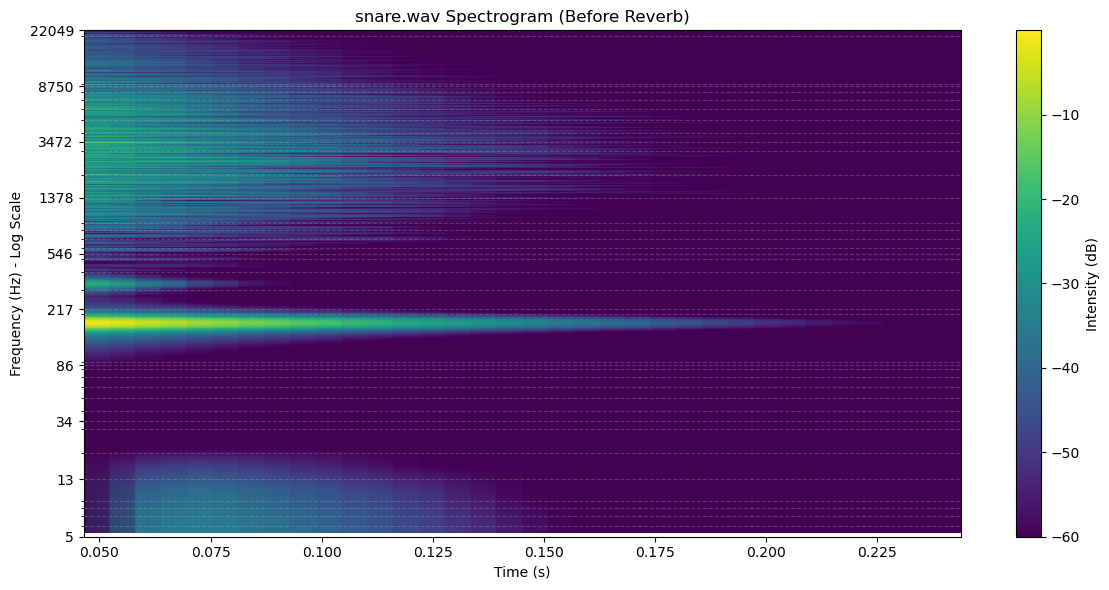

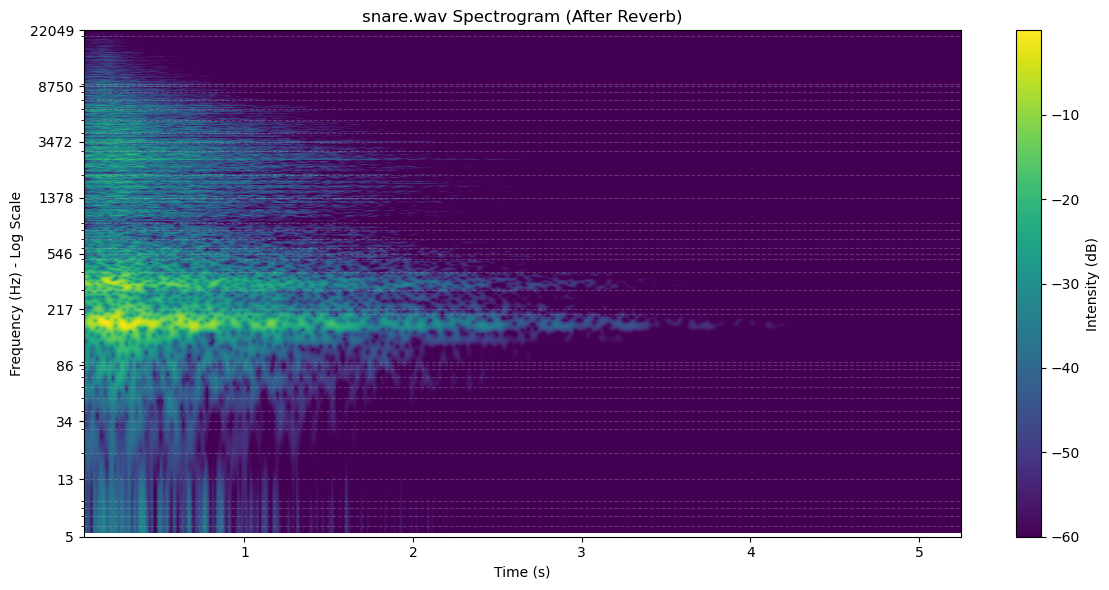

In [17]:
# Load input
inputPath = 'snare.wav'
Fs, x = wavfile.read(inputPath)

input = np.concatenate([x, np.zeros(int(5.0 * Fs), dtype=np.float32)]) #add 5 seconds of zeros to the end of the input

# Allocates a stereo output buffer with one frame per input sample.
output = np.zeros((len(input), 2), dtype=np.float32)

# Processes each mono input sample through reverb function and writes to output 
for i, sample in enumerate(input):
    output[i] = processReverbSample(sample)

# Display audio + spectrograms
display(Audio(x, rate=Fs))
spectrogram(x, Fs, f'{inputPath} Spectrogram (Before Reverb)')
display(Audio(output.T, rate=Fs))
spectrogram(output.mean(axis=1), Fs, f'{inputPath} Spectrogram (After Reverb)')